<a href="https://colab.research.google.com/github/Ozk18532/INTELIGENCIA-COMPUTACIONAL-Oscar-Mercado/blob/main/5_cnn_OscarM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clasificación de imágenes con CNN usando CIFAR-10 en PyTorch**

En esta actividad se implementa un modelo de clasificación multiclase utilizando el conjunto de datos CIFAR-10 incluido en torchvision. El objetivo es entrenar y comparar al menos tres redes neuronales convolucionales con la misma configuración de entrenamiento, cambiando únicamente su arquitectura.

El notebook incluye la carga del dataset, su conversión a tensores, la definición de funciones de entrenamiento y evaluación, el cálculo de curvas de aprendizaje entre entrenamiento y prueba, la selección del mejor modelo de acuerdo con accuracy y una reflexión final sobre los resultados obtenidos.

Como parte adicional, también se implementa una función para clasificar imágenes arbitrarias proporcionadas por el usuario, ajustándolas al formato esperado por el modelo.

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from PIL import Image
from tqdm import tqdm


V = '\033[92m'
R = '\033[91m'
A = '\033[94m'
E = '\033[0m'

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Dispositivo de trabajo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"{A}Dispositivo detectado:{E} {device}")
print(f"{V}PyTorch y librerías cargadas correctamente.{E}")

Dispositivo detectado: cuda
PyTorch y librerías cargadas correctamente.


# Carga del conjunto de datos

Para cumplir con la instrucción de la actividad, se utiliza el dataset CIFAR-10 incluido en torchvision. Este conjunto ya está dividido en train y test, por lo que no será necesario crear un conjunto de validación adicional.

Además, como torchvision carga por defecto las imágenes como objetos tipo PIL.Image, se aplica la transformación ToTensor(), la cual convierte cada imagen a un tensor de PyTorch. Esta transformación es necesaria para poder alimentar correctamente las redes neuronales. El uso de tensores, DataLoader, optimizadores y CrossEntropyLoss forma parte del flujo estándar de PyTorch para clasificación multiclase

In [ ]:
# Transformación obligatoria para convertir PIL.Image -> Tensor
transform = transforms.ToTensor()

# conjunto de entrenamiento
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# conjunto de prueba
test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# clases
classes = train_dataset.classes

print(f"{V}CIFAR-10 cargado correctamente.{E}")
print(f"{A}Número de imágenes de entrenamiento:{E} {len(train_dataset)}")
print(f"{A}Número de imágenes de prueba:{E} {len(test_dataset)}")
print(f"{A}Clases:{E} {classes}")

100%|██████████| 170M/170M [00:04<00:00, 40.9MB/s]


CIFAR-10 cargado correctamente.
Número de imágenes de entrenamiento: 50000
Número de imágenes de prueba: 10000
Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# Preparación de los lotes de datos

Para procesar el dataset por mini-batches se utilizan DataLoader, los cuales permiten recorrer el conjunto de datos en grupos pequeños durante cada época. Esto es importante porque la actividad pide explícitamente que el entrenamiento se realice por mini-batches y que los pesos se actualicen una vez por cada lote procesado. En PyTorch, DataLoader es la herramienta estándar para este propósito.

In [ ]:
# Aquí se crean los cargadores para procesar train y test
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f"{V}DataLoaders creados correctamente.{E}")
print(f"{A}Batch size utilizado:{E} {batch_size}")

DataLoaders creados correctamente.
Batch size utilizado: 128


# Visualización de ejemplos del dataset

Antes de entrenar los modelos, es útil observar algunas imágenes del conjunto de datos para verificar que la carga se realizó correctamente y que las etiquetas corresponden a las clases esperadas.

En CIFAR-10, cada imagen tiene tamaño 32x32 y 3 canales de color (RGB), por lo que la entrada esperada para la CNN será de forma (3, 32, 32). Esto coincide con la estructura típica de una CNN para imágenes descrita en el material de redes convolucionales.

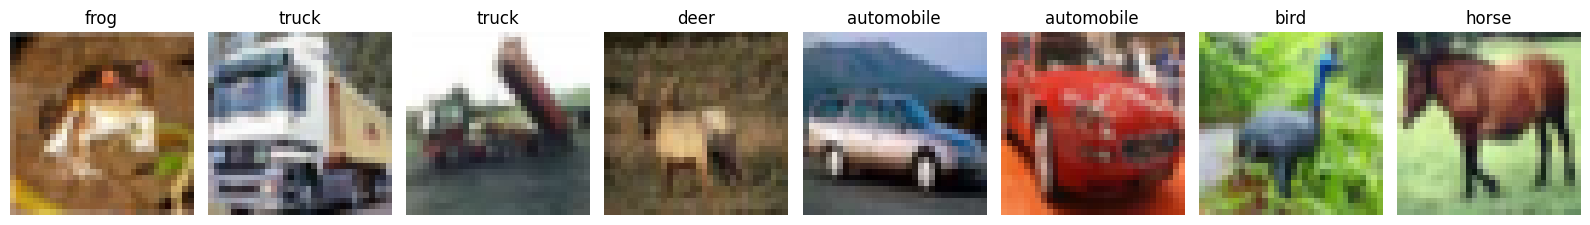

Se desplegaron imágenes de ejemplo correctamente.


In [ ]:
# Cambio realizado: ahora se muestran imágenes RGB de 32x32
# provenientes del dataset oficial CIFAR-10.

def show_images(dataset, class_names, n=8):
    plt.figure(figsize=(16, 4))

    for i in range(n):
        img, label = dataset[i]

        # Convertir de tensor (C,H,W) a formato matplotlib (H,W,C)
        img_np = img.permute(1, 2, 0).numpy()
#⚠️
        plt.subplot(1, n, i + 1)
        plt.imshow(img_np)
        plt.title(class_names[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_images(train_dataset, classes, n=8)

print(f"{V}Se desplegaron imágenes de ejemplo correctamente.{E}")

In [ ]:
# Este bloque confirma que las imágenes ya están convertidas a tensor y tienen la forma correcta para la CNN.
sample_img, sample_label = train_dataset[0]

print(f"{A}Forma de una imagen:{E} {sample_img.shape}")
print(f"{A}Etiqueta numérica:{E} {sample_label}")
print(f"{A}Etiqueta textual:{E} {classes[sample_label]}")

print(f"{V}La imagen ya está en formato tensor gracias a ToTensor().{E}")

Forma de una imagen: torch.Size([3, 32, 32])
Etiqueta numérica: 6
Etiqueta textual: frog
La imagen ya está en formato tensor gracias a ToTensor().


# Definición de arquitecturas CNN

Se definen tres redes neuronales convolucionales distintas. Cada modelo mantiene la misma configuración de entrenamiento, pero cambia su arquitectura, tal como lo requiere la actividad.

Las redes convolucionales permiten extraer patrones espaciales mediante filtros, reduciendo dimensionalidad con pooling y finalmente realizando la clasificación mediante capas fully connected.

In [ ]:

#  MODELO CNN 1 (SIMPLE) Cambio realizado: primera arquitectura base
class CNN_1(nn.Module):
    def __init__(self):
        super(CNN_1, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),  # (3,32,32) -> (16,32,32)
            nn.ReLU(),
            nn.MaxPool2d(2),                             # -> (16,16,16)

            nn.Conv2d(16, 32, kernel_size=3, padding=1), # -> (32,16,16)
            nn.ReLU(),
            nn.MaxPool2d(2)                              # -> (32,8,8)
        )

        self.fc = nn.Sequential(#⚠️
            nn.Flatten(),
            nn.Linear(32*8*8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [ ]:
# MODELO CNN 2 (MAS PROFUNDO) Cambio realizado: se agregan más capas convolucionales
class CNN_2(nn.Module):
    def __init__(self):
        super(CNN_2, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # -> (32,16,16)

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # -> (64,8,8)
        )

        self.fc = nn.Sequential(#⚠️
            nn.Flatten(),
            nn.Linear(64*8*8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

In [ ]:
# MODELO CNN 3 (MAS GRANDE) Cambio realizado: arquitectura más compleja

class CNN_3(nn.Module):
    def __init__(self):
        super(CNN_3, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # (32,16,16)

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # (64,8,8)

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # (128,4,4)
        )

        self.fc = nn.Sequential(#⚠️
            nn.Flatten(),
            nn.Linear(128*4*4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

# Función de pérdida y optimizador

Para este problema de clasificación multiclase se utiliza la función de pérdida CrossEntropyLoss, la cual es estándar para este tipo de tareas.

Para optimización se utiliza Adam, que ajusta los pesos de la red durante el entrenamiento mediante gradientes.

In [ ]:
# LOSS Y OPTIMIZADOR
def get_training_components(model):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=0.001)

    return model, criterion, optimizer

# Loop de entrenamiento

El entrenamiento se realiza por épocas. En cada época se recorren todos los mini-batches del conjunto de entrenamiento. Los pesos se actualizan después de cada batch utilizando backpropagation.

Al finalizar cada época, se evalúa el modelo utilizando el conjunto de prueba para obtener la pérdida correspondiente.

In [ ]:
# FUNCIONES DE ENTRENAMIENTO Y EVALUACIÓN Cambio importante: implementación completa del loop

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)#⚠️

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)#⚠️

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
# ENTRENAMIENTO

def train_model(model_class, epochs=10):
    model = model_class()
    model, criterion, optimizer = get_training_components(model)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        test_loss = evaluate(model, test_loader, criterion)

        train_losses.append(train_loss)#⚠️
        test_losses.append(test_loss)

        print(f"{A}Epoch {epoch+1}/{epochs}{E} | "
              f"{V}Train Loss:{E} {train_loss:.4f} | "
              f"{R}Test Loss:{E} {test_loss:.4f}")

    return model, train_losses, test_losses

# Entrenamiento de los modelos

Se entrenan tres arquitecturas distintas utilizando la misma configuración de entrenamiento. Esto permite comparar el efecto de la arquitectura sobre el desempeño del modelo.

In [ ]:
# ENTRENAR LOS 3 MODELOS
EPOCHS = 10

print(f"{A}Entrenando CNN_1...{E}")
model1, train1, test1 = train_model(CNN_1, epochs=EPOCHS)

print(f"{A}Entrenando CNN_2...{E}")#⚠️
model2, train2, test2 = train_model(CNN_2, epochs=EPOCHS)

print(f"{A}Entrenando CNN_3...{E}")#⚠️
model3, train3, test3 = train_model(CNN_3, epochs=EPOCHS)

print(f"{V}Entrenamiento finalizado para los 3 modelos.{E}")

Entrenando CNN_1...
Epoch 1/10 | Train Loss: 1.6440 | Test Loss: 1.4008
Epoch 2/10 | Train Loss: 1.3298 | Test Loss: 1.2318
Epoch 3/10 | Train Loss: 1.2009 | Test Loss: 1.1654
Epoch 4/10 | Train Loss: 1.1063 | Test Loss: 1.0923
Epoch 5/10 | Train Loss: 1.0327 | Test Loss: 1.0529
Epoch 6/10 | Train Loss: 0.9682 | Test Loss: 1.0184
Epoch 7/10 | Train Loss: 0.9168 | Test Loss: 0.9666
Epoch 8/10 | Train Loss: 0.8725 | Test Loss: 0.9558
Epoch 9/10 | Train Loss: 0.8381 | Test Loss: 0.9266
Epoch 10/10 | Train Loss: 0.7975 | Test Loss: 0.9740
Entrenando CNN_2...
Epoch 1/10 | Train Loss: 1.5675 | Test Loss: 1.3537
Epoch 2/10 | Train Loss: 1.1773 | Test Loss: 1.0703
Epoch 3/10 | Train Loss: 0.9554 | Test Loss: 0.9212
Epoch 4/10 | Train Loss: 0.8100 | Test Loss: 0.8614
Epoch 5/10 | Train Loss: 0.6957 | Test Loss: 0.8107
Epoch 6/10 | Train Loss: 0.6127 | Test Loss: 0.7959
Epoch 7/10 | Train Loss: 0.5202 | Test Loss: 0.7858
Epoch 8/10 | Train Loss: 0.4324 | Test Loss: 0.8656
Epoch 9/10 | Train Loss

# Curvas de aprendizaje

Se grafican las pérdidas de entrenamiento y prueba para analizar el comportamiento de los modelos a lo largo de las épocas.

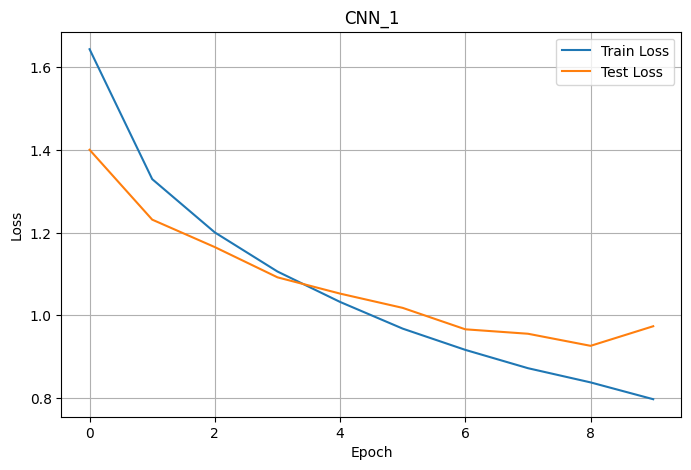

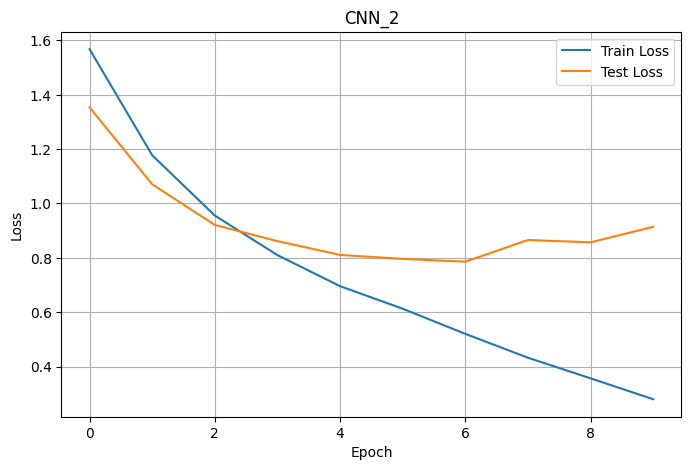

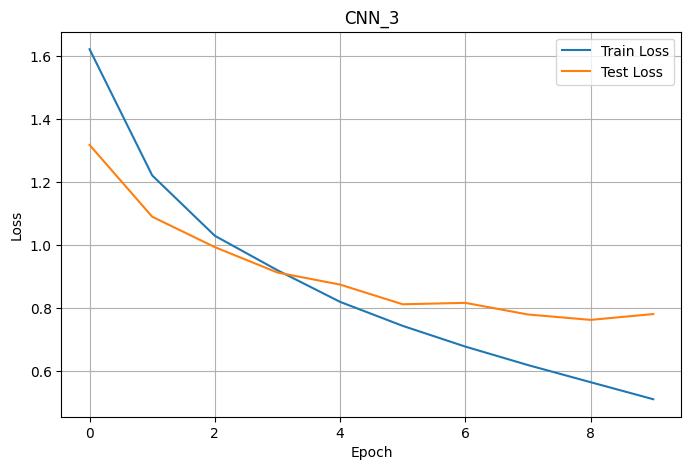

In [ ]:
# GRAFICAR CURVAS
def plot_curves(train_losses, test_losses, title):
    plt.figure(figsize=(8,5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.title(title)
    plt.xlabel("Epoch")#⚠️
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()
    plt.show()

plot_curves(train1, test1, "CNN_1")
plot_curves(train2, test2, "CNN_2")#⚠️
plot_curves(train3, test3, "CNN_3")#⚠️

# Evaluación mediante accuracy

Se calcula el accuracy sobre el conjunto de prueba para cada modelo, con el objetivo de seleccionar el mejor.

In [ ]:
# ACCURACY
def compute_accuracy(model, loader):#⚠️
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

acc1 = compute_accuracy(model1, test_loader)
acc2 = compute_accuracy(model2, test_loader)#⚠️
acc3 = compute_accuracy(model3, test_loader)#⚠️

print(f"{A}Accuracy CNN_1:{E} {acc1:.4f}")
print(f"{A}Accuracy CNN_2:{E} {acc2:.4f}")
print(f"{A}Accuracy CNN_3:{E} {acc3:.4f}")

Accuracy CNN_1: 0.6678
Accuracy CNN_2: 0.7337
Accuracy CNN_3: 0.7419


In [ ]:
# MEJOR MODELO
accuracies = {
    "CNN_1": (model1, acc1),
    "CNN_2": (model2, acc2),
    "CNN_3": (model3, acc3)
}

best_name = max(accuracies, key=lambda x: accuracies[x][1])#⚠️
best_model, best_acc = accuracies[best_name]

print(f"{V}Mejor modelo:{E} {best_name}")
print(f"{V}Accuracy:{E} {best_acc:.4f}")

Mejor modelo: CNN_3
Accuracy: 0.7419


# Clasificación de imágenes arbitrarias

Se implementa una función que recibe la ruta de una imagen, la ajusta al formato requerido por la red (3 canales, 32x32) y devuelve la clase predicha.

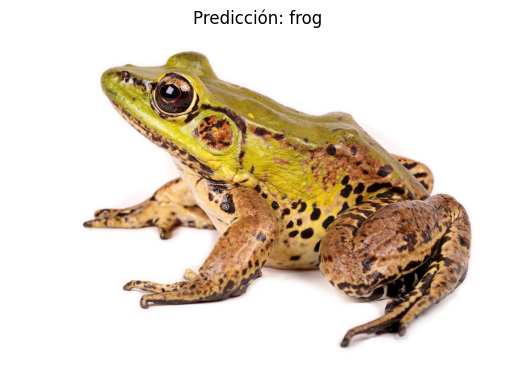

'frog'

In [ ]:
# CLASIFICAR IMAGEN + MOSTRAR RESULTADO imagen junto con la predicción
def predict_image(image_path, model):
    model.eval()

    transform_img = transforms.Compose([#⚠️
        transforms.Resize((32, 32)),
        transforms.ToTensor()
    ])

    # original
    image = Image.open(image_path).convert("RGB")

    # copia
    image_show = image.copy()

    # Transformar
    image = transform_img(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)

    predicted_label = classes[predicted.item()]


    plt.imshow(image_show)#⚠️
    plt.title(f"Predicción: {predicted_label}")
    plt.axis("off")
    plt.show()

    return predicted_label



print(f"{V}Mejor modelo:{E} {best_name}")
predict_image("/content/Rana.jpg", best_model)

# Reflexión
Durante esta actividad se observó que la arquitectura de la red neuronal influye directamente en el desempeño, ya que los modelos más profundos lograron mejores resultados al capturar patrones más complejos.

El uso de mini-batches permitió un entrenamiento eficiente, mientras que las curvas de aprendizaje facilitaron el análisis del comportamiento del modelo a lo largo de las épocas.

Además, la clasificación de imágenes externas permitió comprobar que el modelo generaliza adecuadamente a nuevos datos.

En conjunto, la práctica ayudó a entender el proceso completo de entrenamiento y evaluación de modelos de clasificación con PyTorch.

## ⚠️ Disclaimer

Algunas partes de este notebook fueron asistidas mediante herramientas de inteligencia artificial.

Estas secciones han sido revisadas, comprendidas y adaptadas para cumplir con los objetivos de la actividad.

Las partes asistidas están claramente identificadas con el siguiente icono: ⚠️